# EE 344 — Assignment 6: Power Quality Fault Detection

In this assignment, you will build a structured pipeline for **power quality fault detection** using both supervised and unsupervised learning methods.

You will:
- Preprocess data (OHE + Robust Scaling)
- Perform nonlinear dimensionality reduction (KPCA)
- Train a bottleneck Autoencoder
- Visualize embeddings (3D and t-SNE)
- Apply Kernel SVM for classification
- Perform clustering (K-Means and GMM)
- Compare clustering purity against known labels

Follow instructions carefully.  
Do not modify the provided structure.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load Dataset and Basic Statistics

- Load the dataset file.
- Print shape, columns, missing values.
- Print numeric summary statistics.
- Print label distribution.


In [2]:
# --------------------
# 0) Load the dataset
# --------------------
CSV_PATH = "/content/power_quality_fault_dataset.csv"  # Kaggle dataset file name (same as provided file)
df = pd.read_csv(CSV_PATH)

print("Shape (rows, cols):", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nMissing values per column:")
print(df.isna().sum())

print("\nNumeric summary (describe):")
print(df.describe(include=[np.number]).T)

# Adjust if your CSV uses different names
LABEL_COL = "Fault_Type"
CAT_COL   = "Phase"

print("\nLabel distribution:")
print(df[LABEL_COL].value_counts())

print("\nPhase distribution:")
print(df[CAT_COL].value_counts())

Shape (rows, cols): (2367, 12)

Columns: ['ID', 'Fault_Type', 'Phase', 'RMS_Voltage', 'Peak_Voltage', 'THD', 'Duration_ms', 'DWT_Energy_Level1', 'DWT_Energy_Level2', 'DWT_Entropy', 'Signal_Noise_Ratio_dB', 'Label']

Missing values per column:
ID                       0
Fault_Type               0
Phase                    0
RMS_Voltage              0
Peak_Voltage             0
THD                      0
Duration_ms              0
DWT_Energy_Level1        0
DWT_Energy_Level2        0
DWT_Entropy              0
Signal_Noise_Ratio_dB    0
Label                    0
dtype: int64

Numeric summary (describe):
                        count         mean         std     min      25%  \
ID                     2367.0  1184.000000  683.438366    1.00  592.500   
RMS_Voltage            2367.0   221.905327   39.640015  113.99  223.625   
Peak_Voltage           2367.0   328.814812   66.782209  161.21  317.650   
THD                    2367.0     4.742281    3.329978   -0.25    2.400   
Duration_ms     

## 2. Train/Test Split + Encoding

- Stratify using (Fault_Type, Phase)
- One-Hot Encode Phase (fit on train only)
- Robust scale numeric features only


In [3]:
# --------------------
# 1) Drop columns
# --------------------
DROP_COLS = ["ID", "Label"]  # typical in this dataset; safe to ignore if absent
DROP_COLS = [c for c in DROP_COLS if c in df.columns]
df = df.drop(columns=DROP_COLS)

# --------------------
# 2) Train/test split
# Stratify on joint (Fault_Type, Phase) to preserve both distributions
# --------------------
strata = df[LABEL_COL].astype(str) + "|" + df[CAT_COL].astype(str)

train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=strata
)

print("Train shape:", train_df.shape, " Test shape:", test_df.shape)

Train shape: (1656, 10)  Test shape: (711, 10)


In [4]:
# --------------------
# 3) Encode Fault_Type -> integer labels
# --------------------
target_names = sorted(df[LABEL_COL].unique())
label_map = {name: i for i, name in enumerate(target_names)}

y_train = train_df[LABEL_COL].map(label_map).to_numpy()
y_test  = test_df[LABEL_COL].map(label_map).to_numpy()

print("Label map:", label_map)

# --------------------
# 4) One-hot encode Phase (fit on train only)
# --------------------
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
phase_train_ohe = ohe.fit_transform(train_df[[CAT_COL]])
phase_test_ohe  = ohe.transform(test_df[[CAT_COL]])
phase_cols = ohe.get_feature_names_out([CAT_COL])

# --------------------
# 5) Build numeric matrices (drop label + phase)
# --------------------
X_train_num = train_df.drop(columns=[LABEL_COL, CAT_COL])
X_test_num  = test_df.drop(columns=[LABEL_COL, CAT_COL])

# --------------------
# 6) Robust scale ONLY numeric features, then append OHE as-is
# --------------------
scaler = RobustScaler()
X_train_num_s = scaler.fit_transform(X_train_num)
X_test_num_s  = scaler.transform(X_test_num)

X_train_scaled = pd.concat(
    [
        pd.DataFrame(X_train_num_s, columns=X_train_num.columns).reset_index(drop=True),
        pd.DataFrame(phase_train_ohe, columns=phase_cols).reset_index(drop=True),
    ],
    axis=1
)

X_test_scaled = pd.concat(
    [
        pd.DataFrame(X_test_num_s, columns=X_test_num.columns).reset_index(drop=True),
        pd.DataFrame(phase_test_ohe, columns=phase_cols).reset_index(drop=True),
    ],
    axis=1
)

print("X_train_scaled:", X_train_scaled.shape, " y_train:", y_train.shape)
print("X_test_scaled :", X_test_scaled.shape,  " y_test :", y_test.shape)
print("OHE phase cols:", list(phase_cols))

Label map: {'Harmonics': 0, 'Normal': 1, 'Sag': 2, 'Swell': 3, 'Transient': 4}
X_train_scaled: (1656, 11)  y_train: (1656,)
X_test_scaled : (711, 11)  y_test : (711,)
OHE phase cols: ['Phase_A', 'Phase_B', 'Phase_C']


## Shared Utilities

In [5]:
def eval_classifier(clf, Xtr, ytr, Xte, yte, *, title="Model"):
    clf.fit(Xtr, ytr)

    yhat_tr = clf.predict(Xtr)
    yhat_te = clf.predict(Xte)

    print(f"\n================ {title} ================")

    print("\n--- TRAIN ---")
    print(classification_report(ytr, yhat_tr, target_names=target_names))
    print("Confusion matrix (train):")
    print(confusion_matrix(ytr, yhat_tr))

    print("\n--- TEST ---")
    print(classification_report(yte, yhat_te, target_names=target_names))
    print("Confusion matrix (test):")
    print(confusion_matrix(yte, yhat_te))


def scatter_2d(Z, y, title, xlab="z1", ylab="z2"):
    plt.figure(figsize=(6, 5))
    for i, name in enumerate(target_names):
        m = (y == i)
        plt.scatter(Z[m, 0], Z[m, 1], s=12, label=name)
    plt.title(title)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.legend(title=LABEL_COL, markerscale=1.2, frameon=True)
    plt.show()


def scatter_3d(Z, y, title, xlab="z1", ylab="z2", zlab="z3"):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    for i, name in enumerate(target_names):
        m = (y == i)
        ax.scatter(Z[m, 0], Z[m, 1], Z[m, 2], s=12, label=name)
    ax.set_title(title)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_zlabel(zlab)
    ax.legend(title=LABEL_COL, markerscale=1.2, frameon=True)
    plt.show()

## Part 1 – KPCA (3D) + Kernel SVM (RBF)

**Idea:**  
Kernel PCA uses a **kernel function** (here, RBF) to implicitly map data into a higher-dimensional feature space, then performs PCA there. The goal is to obtain a **low-dimensional embedding** that can reveal structure that is not visible with linear PCA.

This “kernel trick” idea is also used by several classifiers. For example, an **RBF Kernel SVM** also uses an implicit high-dimensional mapping, but instead of PCA it searches for a **linear separating hyperplane in that feature space** (which corresponds to a nonlinear boundary in the original space).

### Tasks
1. Apply Kernel PCA with RBF kernel to reduce data to 3 dimensions.
2. Visualize train embedding in 3D.
3. Train an RBF Kernel SVM using the KPCA features.
4. Print classification report and confusion matrix for train and test.

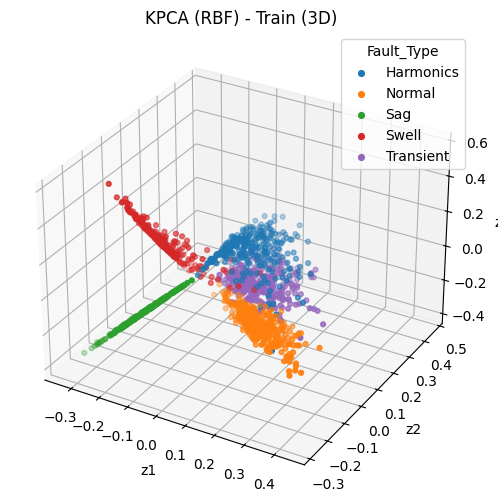

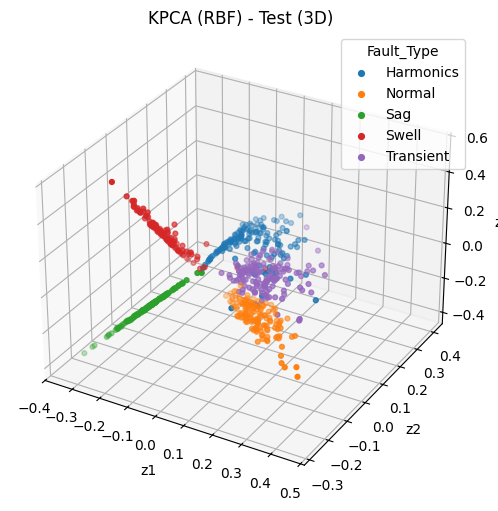


================ KPCA(3D) + RBF SVM ================

--- TRAIN ---
              precision    recall  f1-score   support

   Harmonics       0.94      0.88      0.91       339
      Normal       0.96      0.99      0.98       345
         Sag       1.00      1.00      1.00       327
       Swell       1.00      0.99      0.99       315
   Transient       0.87      0.91      0.89       330

    accuracy                           0.95      1656
   macro avg       0.95      0.95      0.95      1656
weighted avg       0.95      0.95      0.95      1656

Confusion matrix (train):
[[297   3   0   0  39]
 [  0 342   0   1   2]
 [  0   0 327   0   0]
 [  0   1   0 311   3]
 [ 20  10   0   0 300]]

--- TEST ---
              precision    recall  f1-score   support

   Harmonics       0.95      0.85      0.90       146
      Normal       0.97      0.99      0.98       147
         Sag       1.00      0.99      1.00       140
       Swell       1.00      0.99      1.00       135
   Transient   

In [6]:
from sklearn.decomposition import KernelPCA
from sklearn.svm import SVC

Xtr = X_train_scaled.to_numpy(dtype=np.float32)
Xte = X_test_scaled.to_numpy(dtype=np.float32)

# -------------------------
# TODO 1A: KPCA (RBF) 3D
# -------------------------
# Create a KernelPCA object with:
# - n_components = 3
# - kernel = "rbf"
# - gamma = 0.005
# - random_state = 42
#
# Then:
# - Fit KPCA on Xtr only
# - Transform Xtr and Xte
# - Produce:
#   - Z_kpca3_train with shape (n_train, 3)
#   - Z_kpca3_test  with shape (n_test,  3)

kpca = KernelPCA(
    n_components=3,
    kernel="rbf",
    gamma=0.5,
    random_state=RANDOM_STATE
)
Z_kpca3_train = kpca.fit_transform(Xtr)
Z_kpca3_test  = kpca.transform(Xte)

# -------------------------
# Provided: visualization
# -------------------------
scatter_3d(Z_kpca3_train, y_train, "KPCA (RBF) - Train (3D)")
scatter_3d(Z_kpca3_test,  y_test,  "KPCA (RBF) - Test (3D)")

# -------------------------
# TODO 1B: Kernel SVM (RBF) on KPCA features
# -------------------------
# Create an RBF-kernel SVM with:
# - kernel = "rbf"
# - C = 10.0
# - gamma = "scale"
# - random_state = 42
#
# Then evaluate using:
# eval_classifier(svm_rbf_kpca, Z_kpca3_train, y_train, Z_kpca3_test, y_test, title="KPCA(3D) + RBF-SVM")

svm_rbf_kpca = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

eval_classifier(
    svm_rbf_kpca,
    Z_kpca3_train,
    y_train,
    Z_kpca3_test,
    y_test,
    title="KPCA(3D) + RBF SVM"
)

## Part 2 – Autoencoder Embedding (3D) + Kernel SVM (RBF)

In this part, you will train a **multi-head autoencoder** that reconstructs:
- the **numeric features** (MSE), and
- the **phase category** (cross-entropy on phase logits).

You will use the **3D bottleneck** as a learned embedding for:
- 3D visualization, and
- RBF Kernel SVM classification.

### Architecture (Encoder/Decoder)
- Encoder: `input_dim → 6 → 3`
- Decoder trunk: `3 → 6 → { numeric head, phase head }`

**Important:**
- Use **BatchNorm + Dropout** in the hidden layers.
- Use **no activation on the bottleneck** (linear only).
- Train with `lr = 1e-2`, `batch_size = 512`.
- Print **average epoch loss** every `100` epochs.

### Tasks
1. Prepare numeric vs phase parts of the input (phase index labels from one-hot).
2. Implement the `MultiHeadAE` model (encoder + 2 decoder heads).
3. Implement the training loop (MSE + λ·CE) and print average epoch loss.
4. Train the model with `latent_dim = 3` and visualize the embedding (3D).
5. Train an **RBF Kernel SVM** on the learned 3D embeddings and report:
   - confusion matrix + classification report (train and test).

In [7]:
# ===== Autoencoder 3D (BN+Dropout; NOTHING on bottleneck)
# Required:
#   - lr = 1e-2
#   - batch_size = 512
#   - print average epoch loss every 100 epochs

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Assumes you already have:
# - X_train_scaled, X_test_scaled (pandas DataFrame or numpy array)
# - phase_cols (list of OHE phase columns, same order used in X_train_scaled)
# - y_train, y_test, target_names

phase_cols = list(phase_cols)
n_cat = len(phase_cols)

Xtr = np.asarray(X_train_scaled, dtype=np.float32)
Xte = np.asarray(X_test_scaled,  dtype=np.float32)

n_total = Xtr.shape[1]
n_num = n_total - n_cat

# Numeric portion (for MSE recon)
Xtr_num = Xtr[:, :n_num]
Xte_num = Xte[:, :n_num]

# Phase index labels (for CE on phase logits)
tr_phase_idx = Xtr[:, n_num:].argmax(axis=1).astype(np.int64)
te_phase_idx = Xte[:, n_num:].argmax(axis=1).astype(np.int64)

# Torch tensors (keep on CPU; move per-batch to device in training loop)
Xtr_t = torch.from_numpy(Xtr)
Xte_t = torch.from_numpy(Xte)

Xtr_num_t = torch.from_numpy(Xtr_num)
Xte_num_t = torch.from_numpy(Xte_num)

tr_phase_idx_t = torch.from_numpy(tr_phase_idx)
te_phase_idx_t = torch.from_numpy(te_phase_idx)

print("n_total:", n_total, "| n_num:", n_num, "| n_cat:", n_cat)

Device: cpu
n_total: 11 | n_num: 8 | n_cat: 3


In [8]:
class MultiHeadAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, n_num, n_cat, p_drop=0.1):
        super().__init__()

        # -------------------------
        # TODO 2A: Encoder
        # input_dim -> hidden_dim -> latent_dim
        # - hidden: BatchNorm + ReLU + Dropout
        # - bottleneck: linear only (NO activation, NO BN, NO dropout)
        # -------------------------
        self.enc_fc1 = nn.Linear(input_dim, hidden_dim)
        self.enc_bn1 = nn.BatchNorm1d(hidden_dim)
        self.enc_do1 = nn.Dropout(p_drop)
        self.enc_fc2 = nn.Linear(hidden_dim, latent_dim)

        # -------------------------
        # TODO 2B: Decoder trunk
        # latent_dim -> hidden_dim
        # - hidden: BatchNorm + ReLU + Dropout
        # -------------------------
        self.dec_fc1 = nn.Linear(latent_dim, hidden_dim)
        self.dec_bn1 = nn.BatchNorm1d(hidden_dim)
        self.dec_do1 = nn.Dropout(p_drop)

        # -------------------------
        # TODO 2C: Decoder heads
        # - Numeric head: hidden_dim -> n_num (linear)
        # - Phase head : hidden_dim -> n_cat (logits, no softmax)
        # -------------------------
        self.dec_num = nn.Linear(hidden_dim, n_num)
        self.dec_cat =  nn.Linear(hidden_dim, n_cat)

    def encode(self, x):
        # -------------------------
        # TODO 2D: Implement encoder forward pass and return latent z
        # -------------------------
        h = self.enc_fc1(x)
        h = self.enc_bn1(h)
        h = torch.relu(h)
        h = self.enc_do1(h)
        z = self.enc_fc2(h)
        return z

    def forward(self, x):
        # -------------------------
        # TODO 2E: Implement forward pass
        # Return: (z, x_num_hat, phase_logits)
        # -------------------------
        z = self.encode(x)

        h = self.dec_fc1(z)
        h = self.dec_bn1(h)
        h = torch.relu(h)
        h = self.dec_do1(h)

        x_num_hat = self.dec_num(h)
        phase_logits = self.dec_cat(h)

        return z, x_num_hat, phase_logits

In [9]:
def train_and_embed(
    *,
    epochs=1000,
    batch_size=512,
    lr=1e-2,
    lambda_ce=0.005,
    print_every=100
):
    # Fixed for this assignment:
    # hidden_dim=6, latent_dim=3, dropout p=0.1
    model = MultiHeadAE(
        input_dim=n_total,
        hidden_dim=6,
        latent_dim=3,
        n_num=n_num,
        n_cat=n_cat,
        p_drop=0.1
    ).to(device)

    mse = nn.MSELoss()
    ce  = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    ds = TensorDataset(Xtr_t, Xtr_num_t, tr_phase_idx_t)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(1, epochs + 1):
        total_loss = 0.0

        for xb, xb_num, ph_idx in dl:
            xb = xb.to(device)
            xb_num = xb_num.to(device)
            ph_idx = ph_idx.to(device)

            # -------------------------
            # TODO 2F: Training step
            # - Forward pass to get (z, x_num_hat, phase_logits)
            # - Compute: mse(x_num_hat, xb_num) + lambda_ce * ce(phase_logits, ph_idx)
            # - Backprop + update
            # - Accumulate total_loss (weighted by batch size)
            # -------------------------
            z, x_num_hat, phase_logits = model(xb)
            loss = mse(x_num_hat, xb_num) + lambda_ce * ce(phase_logits, ph_idx)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item() * xb.size(0)

        if (epoch % print_every) == 0 or epoch == 1:
            avg_loss = total_loss / len(ds)
            print(f"Epoch {epoch:04d}/{epochs} | loss={avg_loss:.6f}")

    model.eval()
    with torch.no_grad():
        # -------------------------
        # TODO 2G: Compute embeddings using model.encode(...)
        # - Ztr: (n_train, 3)
        # - Zte: (n_test,  3)
        # -------------------------
        Ztr = model.encode(Xtr_t.to(device)).cpu().numpy()
        Zte = model.encode(Xte_t.to(device)).cpu().numpy()

    return model, Ztr, Zte

Epoch 0001/1000 | loss=1.598281
Epoch 0100/1000 | loss=0.375022
Epoch 0200/1000 | loss=0.383452
Epoch 0300/1000 | loss=0.390621
Epoch 0400/1000 | loss=0.380005
Epoch 0500/1000 | loss=0.379515
Epoch 0600/1000 | loss=0.375595
Epoch 0700/1000 | loss=0.390768
Epoch 0800/1000 | loss=0.377130
Epoch 0900/1000 | loss=0.376330
Epoch 1000/1000 | loss=0.373850


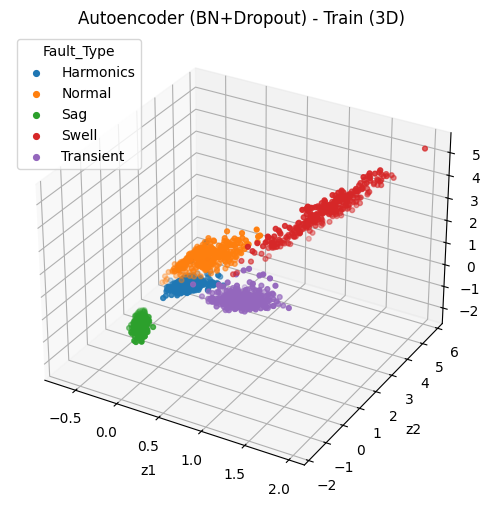

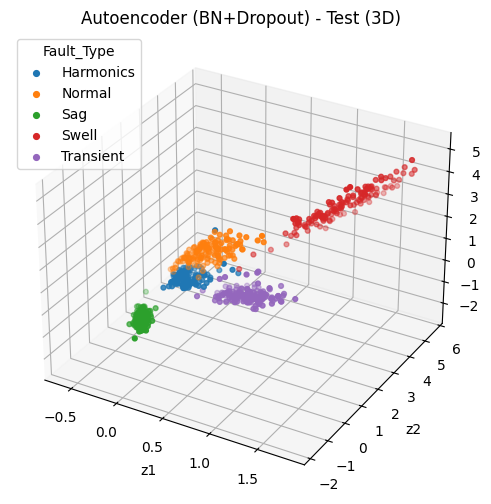


================ AE(3D) + RBF-SVM ================

--- TRAIN ---
              precision    recall  f1-score   support

   Harmonics       0.99      0.99      0.99       339
      Normal       0.97      1.00      0.99       345
         Sag       1.00      1.00      1.00       327
       Swell       1.00      0.99      1.00       315
   Transient       1.00      0.99      0.99       330

    accuracy                           0.99      1656
   macro avg       0.99      0.99      0.99      1656
weighted avg       0.99      0.99      0.99      1656

Confusion matrix (train):
[[335   4   0   0   0]
 [  0 345   0   0   0]
 [  0   0 327   0   0]
 [  1   2   0 312   0]
 [  1   3   0   0 326]]

--- TEST ---
              precision    recall  f1-score   support

   Harmonics       0.99      0.99      0.99       146
      Normal       0.99      1.00      0.99       147
         Sag       1.00      1.00      1.00       140
       Swell       1.00      0.99      1.00       135
   Transient     

In [10]:
from sklearn.svm import SVC

# -------------------------
# TODO 2H: Train AE and get 3D embeddings
# -------------------------
# Required settings:
# - epochs=1000
# - lr=1e-2
# - batch_size=512
# - lambda_ce=0.005
ae_model, Z_ae3_train, Z_ae3_test = train_and_embed(
    epochs=1000,
    batch_size=512,
    lr=1e-2,
    lambda_ce=0.005
)

scatter_3d(Z_ae3_train, y_train, "Autoencoder (BN+Dropout) - Train (3D)")
scatter_3d(Z_ae3_test,  y_test,  "Autoencoder (BN+Dropout) - Test (3D)")

# -------------------------
# TODO 2I: Kernel SVM (RBF) on AE embeddings
# -------------------------
# Required hyperparameters:
# - kernel="rbf"
# - C=10.0
# - gamma="scale"
# - random_state=42
#
# Then evaluate using:
# eval_classifier(
#     svm_rbf_ae,
#     Z_ae3_train, y_train,
#     Z_ae3_test,  y_test,
#     title="AE(3D) + RBF-SVM"
# )
svm_rbf_ae = SVC(
    kernel="rbf",
    C=10.0,
    gamma="scale",
    random_state=42
)

eval_classifier(
    svm_rbf_ae,
    Z_ae3_train, y_train,
    Z_ae3_test,  y_test,
    title="AE(3D) + RBF-SVM"
)

## Part 3 – t-SNE (2D)

### Tasks
- Apply t-SNE (2D) on robust-scaled train data.
- Visualize class separation.


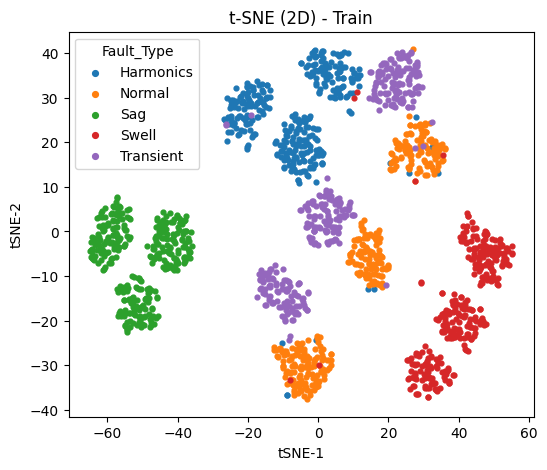

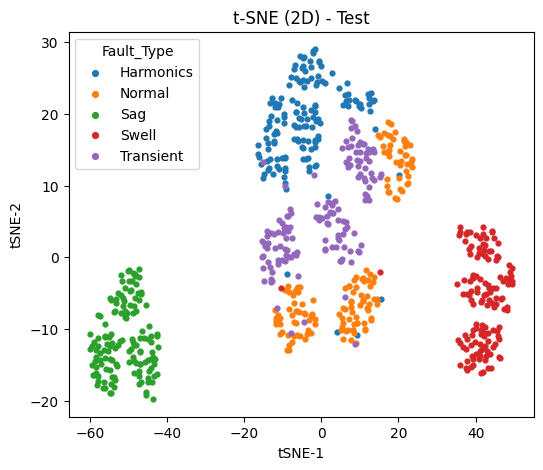

In [11]:
from sklearn.manifold import TSNE

# -------------------------
# TODO 3A: t-SNE 2D on train
# -------------------------
# Create a TSNE object with:
# - n_components = 2
# - perplexity = 30
# - init = "pca"
# - learning_rate = "auto"
# - random_state = 42
#
# Compute the 2D embedding for the training set and store it in Z_tsne_train.

tsne_tr = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=RANDOM_STATE
)
Z_tsne_train = tsne_tr.fit_transform(X_train_scaled)

scatter_2d(Z_tsne_train, y_train, "t-SNE (2D) - Train", xlab="tSNE-1", ylab="tSNE-2")

# -------------------------
# TODO 3B: t-SNE 2D on test (fit separately)
# -------------------------
# Use the SAME TSNE hyperparameters as above, but run t-SNE separately on the test set.
# Store the 2D embedding in Z_tsne_test.

tsne_te = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=RANDOM_STATE
)

Z_tsne_test = tsne_te.fit_transform(X_test_scaled)

scatter_2d(Z_tsne_test, y_test, "t-SNE (2D) - Test", xlab="tSNE-1", ylab="tSNE-2")

## Part 4 – K-Means Clustering

### Tasks
- Compute WCSS for k=2 to 15.
- Compute Silhouette score.
- Compute Fowlkes-Mallows Index.
- Identify best k.
- Print within-cluster class distribution (percentage).


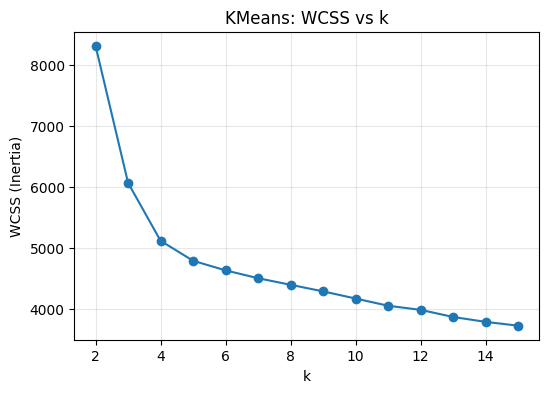

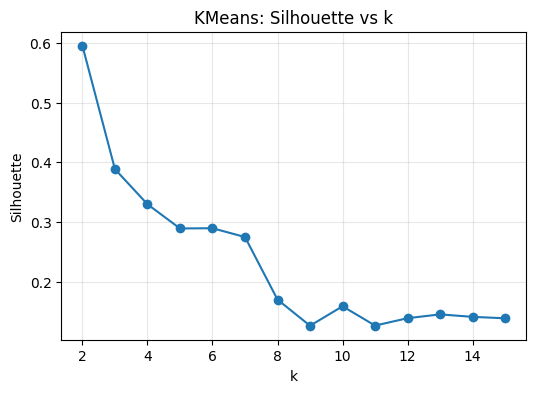

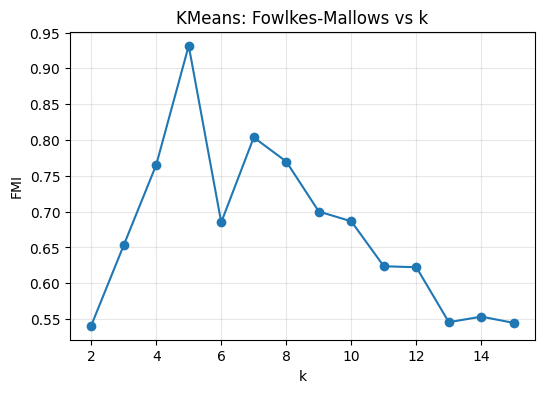

     k         wcss  silhouette       fmi
0    2  8316.505211    0.595511  0.540796
1    3  6064.839786    0.388609  0.652993
2    4  5113.327706    0.329751  0.765210
3    5  4784.891084    0.289139  0.931569
4    6  4627.235193    0.289526  0.685031
5    7  4498.305099    0.274746  0.803614
6    8  4390.214133    0.169827  0.769934
7    9  4282.123429    0.126053  0.700199
8   10  4164.536596    0.158633  0.686492
9   11  4046.140053    0.126319  0.623785
10  12  3978.561583    0.138688  0.622405
11  13  3861.521920    0.145071  0.545718
12  14  3781.393272    0.140908  0.553491
13  15  3718.342057    0.138509  0.544695


In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, fowlkes_mallows_score

k_values = list(range(2, 16))

wcss = []
sil = []
fmi = []

# -------------------------
# TODO 4A: K-Means sweep on TRAIN
# -------------------------
# For each k in k_values:
# - Run KMeans with n_init=20, random_state=42
# - Collect:
#   - WCSS (inertia)
#   - silhouette score
#   - Fowlkes–Mallows index (compare clusters vs y_train)

for k in k_values:
    km = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=RANDOM_STATE
    )
    c_tr = km.fit_predict(X_train_scaled)

    wcss.append(km.inertia_)
    sil.append(silhouette_score(X_train_scaled, c_tr))
    fmi.append(fowlkes_mallows_score(y_train, c_tr))

# -------------------------
# Provided: plotting + table wrapper
# -------------------------
def plot_k_curve(k_vals, ys, title, ylab):
    plt.figure(figsize=(6, 4))
    plt.plot(k_vals, ys, marker="o")
    plt.title(title)
    plt.xlabel("k")
    plt.ylabel(ylab)
    plt.grid(True, alpha=0.3)
    plt.show()

plot_k_curve(k_values, wcss, "KMeans: WCSS vs k", "WCSS (Inertia)")
plot_k_curve(k_values, sil,  "KMeans: Silhouette vs k", "Silhouette")
plot_k_curve(k_values, fmi,  "KMeans: Fowlkes-Mallows vs k", "FMI")

results_km = pd.DataFrame({"k": k_values, "wcss": wcss, "silhouette": sil, "fmi": fmi})
print(results_km)

In [14]:
BEST_K = 5

km = KMeans(n_clusters=BEST_K, n_init=50, random_state=RANDOM_STATE)
c_tr = km.fit_predict(X_train_scaled)
c_te = km.predict(X_test_scaled)

def cluster_purity_percent(clusters, y, split_name):
    tab = pd.crosstab(
        pd.Series(clusters, name="Cluster"),
        pd.Series([target_names[i] for i in y], name="Class")
    )
    tab["Total"] = tab.sum(axis=1)

    pct = (tab.drop(columns=["Total"]).div(tab["Total"], axis=0) * 100).round(2)
    print(f"\n=== {split_name}: within-cluster class % ===")
    print(pct)

cluster_purity_percent(c_tr, y_train, "TRAIN")
cluster_purity_percent(c_te, y_test,  "TEST")


=== TRAIN: within-cluster class % ===
Class    Harmonics  Normal    Sag   Swell  Transient
Cluster                                             
0             0.00    0.00    0.0  100.00       0.00
1             0.00    0.00  100.0    0.00       0.00
2            99.35    0.00    0.0    0.00       0.65
3             5.70   89.38    0.0    2.33       2.59
4             3.31    0.00    0.0    0.90      95.78

=== TEST: within-cluster class % ===
Class    Harmonics  Normal    Sag   Swell  Transient
Cluster                                             
0             0.00     0.0    0.0  100.00       0.00
1             0.00     0.0  100.0    0.00       0.00
2           100.00     0.0    0.0    0.00       0.00
3             8.93    87.5    0.6    0.00       2.98
4             0.00     0.0    0.0    1.43      98.57


## Part 5 – Gaussian Mixture Model

### Tasks
- Compute BIC and AIC for k=1 to 15.
- Compute Fowlkes-Mallows Index.
- Identify best k.
- Print within-cluster class distribution (percentage).


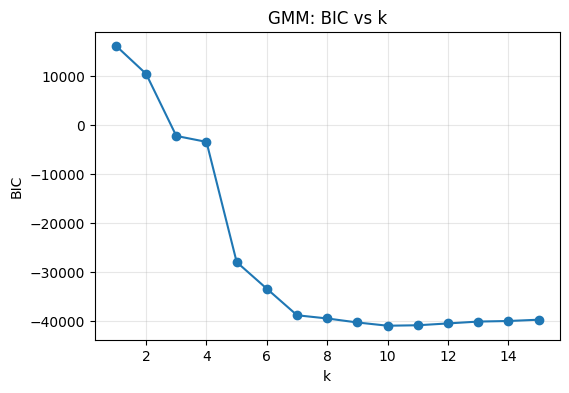

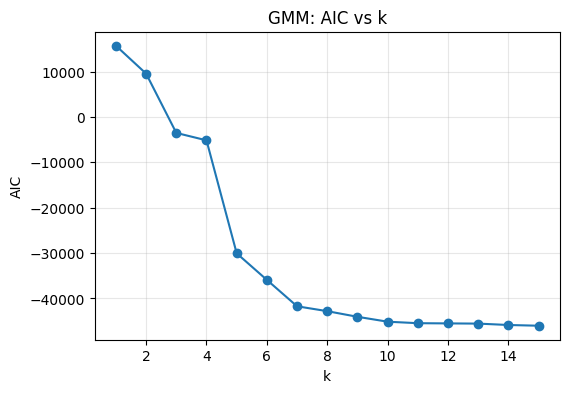

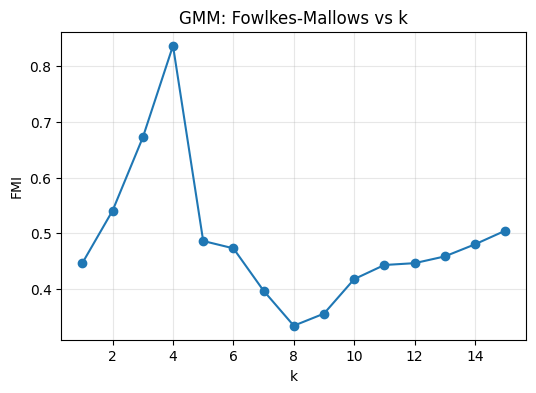

     k           bic           aic       fmi
0    1  16128.642582  15711.906236  0.446890
1    2  10397.251375   9558.366523  0.540796
2    3  -2251.788271  -3512.821629  0.671967
3    4  -3466.301142  -5149.483006  0.836498
4    5 -27956.152882 -30061.483253  0.486342
5    6 -33391.440531 -35918.919407  0.473149
6    7 -38786.946082 -41736.573465  0.397120
7    8 -39440.782328 -42812.558217  0.334367
8    9 -40258.677715 -44052.602110  0.356062
9   10 -40917.714488 -45133.787389  0.417928
10  11 -40824.518532 -45462.739939  0.443273
11  12 -40448.987929 -45509.357842  0.446539
12  13 -40071.094880 -45553.613300  0.458646
13  14 -39955.601895 -45860.268820  0.480314
14  15 -39693.338970 -46020.154402  0.504735


In [15]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import fowlkes_mallows_score

k_values = list(range(1, 16))

bic = []
aic = []
fmi = []

COV_TYPE = "full"  # try: "full", "diag", "tied", "spherical"

# -------------------------
# TODO 5A: GMM sweep on TRAIN
# -------------------------
# For each k in k_values:
# - Run GaussianMixture with:
#   - n_components = k
#   - covariance_type = COV_TYPE
#   - n_init = 20
#   - random_state = 42
# - Collect:
#   - BIC
#   - AIC
#   - Fowlkes–Mallows index (compare clusters vs y_train)

for k in k_values:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type=COV_TYPE,
        n_init=20,
        random_state=RANDOM_STATE
    )

    gmm.fit(X_train_scaled)
    c_tr = gmm.predict(X_train_scaled)

    bic.append(gmm.bic(X_train_scaled))
    aic.append(gmm.aic(X_train_scaled))
    fmi.append(fowlkes_mallows_score(y_train, c_tr))

plot_k_curve(k_values, bic, "GMM: BIC vs k", "BIC")
plot_k_curve(k_values, aic, "GMM: AIC vs k", "AIC")
plot_k_curve(k_values, fmi, "GMM: Fowlkes-Mallows vs k", "FMI")

results_gmm = pd.DataFrame({"k": k_values, "bic": bic, "aic": aic, "fmi": fmi})
print(results_gmm)

In [16]:
BEST_K = 4

gmm = GaussianMixture(
    n_components=BEST_K,
    covariance_type=COV_TYPE,
    n_init=50,
    random_state=RANDOM_STATE
)
gmm.fit(X_train_scaled)

c_tr = gmm.predict(X_train_scaled)
c_te = gmm.predict(X_test_scaled)

cluster_purity_percent(c_tr, y_train, "TRAIN (GMM)")
cluster_purity_percent(c_te, y_test,  "TEST (GMM)")


=== TRAIN (GMM): within-cluster class % ===
Class    Harmonics  Normal    Sag  Swell  Transient
Cluster                                            
0             0.00    0.00    0.0   0.00      100.0
1             0.00    0.00  100.0   0.00        0.0
2            33.93   34.53    0.0  31.53        0.0
3             0.00    0.00  100.0   0.00        0.0

=== TEST (GMM): within-cluster class % ===
Class    Harmonics  Normal    Sag  Swell  Transient
Cluster                                            
0             0.00    0.00    0.0   0.00      100.0
1             0.00    0.00  100.0   0.00        0.0
2            34.11   34.35    0.0  31.54        0.0
3             0.00    0.00  100.0   0.00        0.0


## Part 6 – Discussion

Compare K-Means vs GMM clustering on this dataset where the true labels are known.

Focus on:
1) Whether clusters look “pure” (one dominant class per cluster),
2) Whether the best k is close to the number of true classes,
3) How consistent the cluster purity is between train and test.

Which clustering method is better here, and why?


The clusters appear fairly pure, with most clusters dominated by a single fault class. This can also be seen in the t-SNE visualization, where samples from the same class form compact groups.

For K-mean, the best k = 5 matches the number of true classes in the dataset. This suggests that K-Means is able to recover the underlying structure of the data well .For GMM, the best FMI occurs at k = 4, which is slightly different from the true number of classes, indicating that some classes may be merged.

The cluster purity is also consistent between the train and test sets, as the groups remain well separated in both visualizations.
Overall, K-Means performs better on this dataset because its optimal number of clusters matches the true class count.